# Event-Driven Congestion - Forecasting Traffic Impact & Recommending Resources

**Hackathon theme:** *Event-Driven Congestion (Planned & Unplanned)*

Political rallies, festivals, sports events, construction and sudden gatherings create localized traffic breakdowns. Today:
- Event impact is **not quantified in advance**.
- Resource deployment is **experience-driven** (gut feel).
- There is **no post-event learning system**.

**Problem statement:** *How can historical and real-time data be used to forecast event-related traffic impact and recommend optimal manpower, barricading and diversion plans?*

---

## Our approach

We use the **Astram** event log (~8,200 real traffic events in Bengaluru, Nov 2023 - Apr 2024). From it we learn two models and a recommender:

| Component | Type | Answers |
|-----------|------|---------|
| **Clearance-duration model** | Regression | *How long will this event block the road?* (impact proxy) |
| **Road-closure model** | Classification | *Will barricading / diversion be needed?* |
| **Resource recommender** | Rule engine on top of the models | *How many officers, how many barricades, divert or not?* |

The feature-engineering and training code lives in the reusable `ml/` package in `../backend`, so the **exact same logic** runs here (for training) and in the FastAPI backend (for live prediction). This notebook explains and exercises that code.

In [1]:
# --- Standard imports -------------------------------------------------------
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

# Make the shared ml package importable (it lives in ../backend).
sys.path.insert(0, os.path.abspath('../backend'))
from ml.features import (
    load_raw, add_targets, build_features,
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, ALL_FEATURES,
)

CSV = '../Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv'
raw = load_raw(CSV)
print('Rows, Columns:', raw.shape)

Rows, Columns: (8173, 46)


## 1. Get to know the data

Each row is a single traffic event with a location, a cause, timestamps and operational metadata. Let's look at the most relevant columns.

In [2]:
cols = ['event_type','event_cause','priority','veh_type','corridor','zone',
        'requires_road_closure','status','latitude','longitude','start_datetime']
raw[cols].head()

,event_type,event_cause,priority,veh_type,corridor,zone,requires_road_closure,status,latitude,longitude,start_datetime
0,unplanned,vehicle_breakdown,High,lcv,Tumkur Road,NaN,False,closed,13.040004,77.518099,2024-03-07 17:01:48.111+00
1,unplanned,vehicle_breakdown,High,heavy_vehicle,ORR East 1,NaN,False,resolved,12.921876,77.645158,2024-01-30 04:07:24.173+00
2,unplanned,others,Low,NaN,Non-corridor,Central Zone 2,False,closed,12.955622,77.585708,2023-11-11 06:18:03.343+00
3,unplanned,tree_fall,Low,NaN,Non-corridor,NaN,True,closed,13.006147,77.579435,2024-03-07 17:56:55.061+00
4,unplanned,vehicle_breakdown,Low,private_bus,Non-corridor,NaN,False,closed,12.953980,77.585233,2024-01-30 04:56:32.348+00


In [3]:
# Missingness of the columns we care about (a key data-quality check).
(raw[cols].isna().mean().mul(100).round(1)
     .sort_values(ascending=False).rename('percent_missing').to_frame())

,percent_missing
zone,57.9
veh_type,40.2
corridor,0.2
event_type,0.0
event_cause,0.0
priority,0.0
requires_road_closure,0.0
status,0.0
latitude,0.0
longitude,0.0


## 2. Exploratory data analysis

### 2.1 What kinds of events occur?
The dataset is dominated by **unplanned** events (mostly vehicle breakdowns), but the costly congestion comes from a long tail of construction, water-logging, accidents, processions and public events.

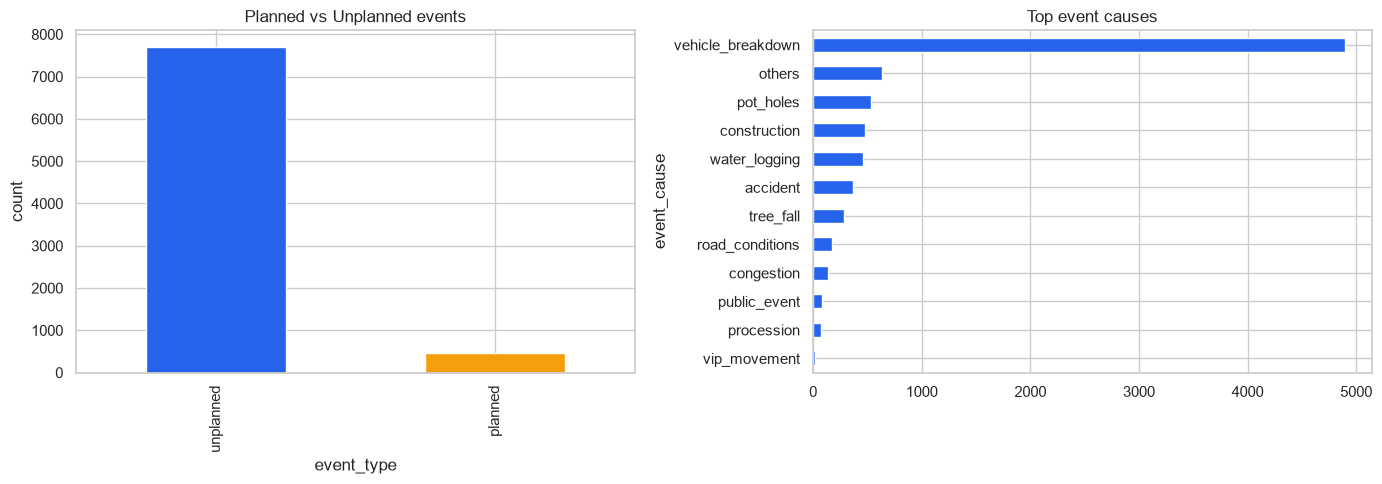

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
raw['event_type'].value_counts().plot.bar(ax=axes[0], color=['#2563eb','#f59e0b'])
axes[0].set_title('Planned vs Unplanned events'); axes[0].set_ylabel('count')
raw['event_cause'].value_counts().head(12).plot.barh(ax=axes[1], color='#2563eb')
axes[1].set_title('Top event causes'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### 2.2 When do events happen?
Temporal structure is a strong signal for resource planning - peak-hour events on arterial corridors are the ones that snowball.

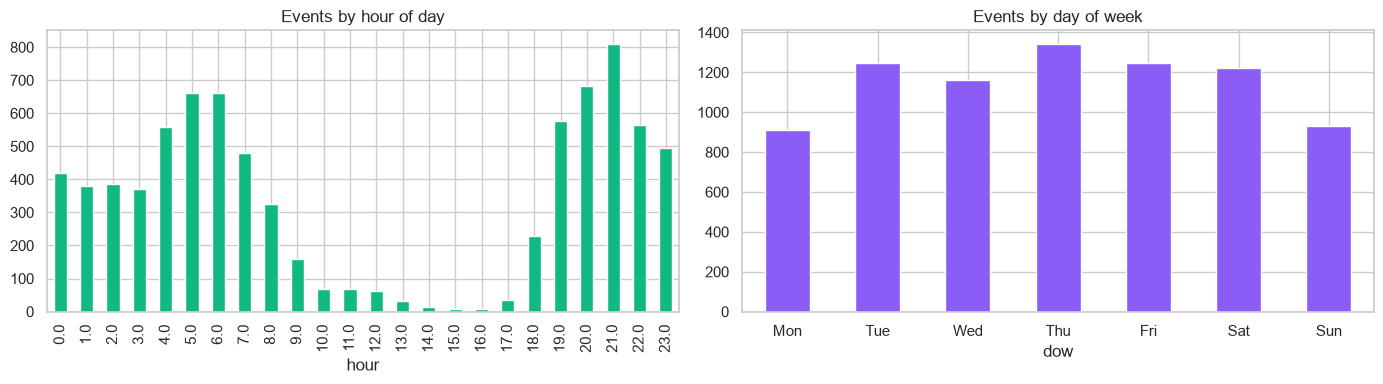

In [5]:
start = pd.to_datetime(raw['start_datetime'], errors='coerce', utc=True)
tmp = pd.DataFrame({'hour': start.dt.hour, 'dow': start.dt.dayofweek})
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tmp['hour'].value_counts().sort_index().plot.bar(ax=axes[0], color='#10b981')
axes[0].set_title('Events by hour of day'); axes[0].set_xlabel('hour')
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
tmp['dow'].value_counts().sort_index().plot.bar(ax=axes[1], color='#8b5cf6')
axes[1].set_xticklabels(days, rotation=0); axes[1].set_title('Events by day of week')
plt.tight_layout(); plt.show()

### 2.3 Where do events happen? (corridors & closures)
Arterial **corridors** carry the most traffic, so an event there has outsized impact. About **8%** of events require a road closure - exactly the cases that need barricades and diversions.

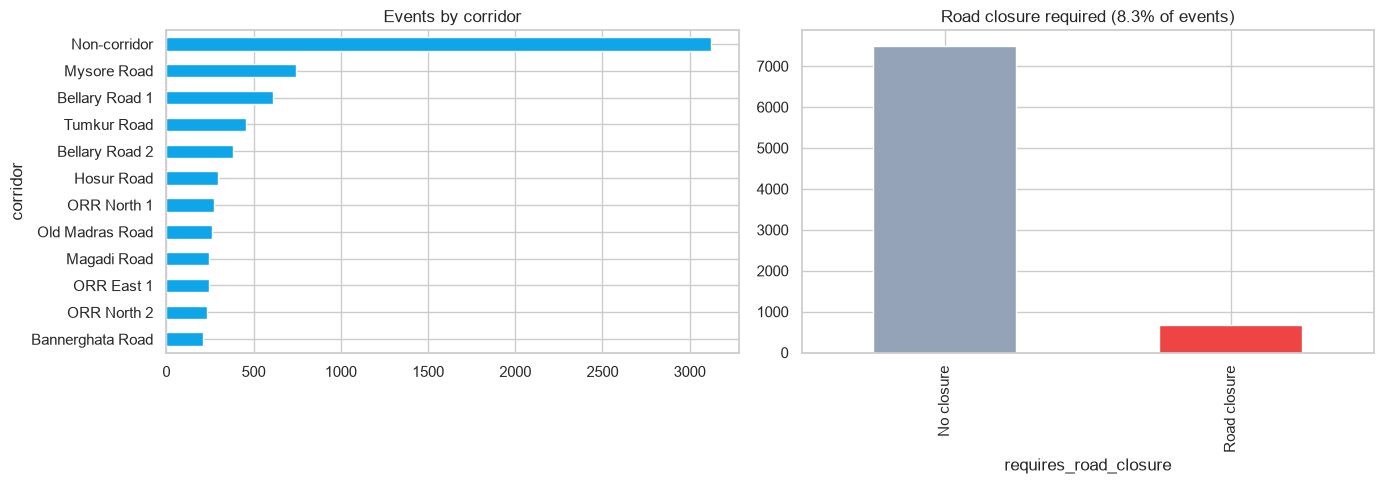

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
raw['corridor'].value_counts().head(12).plot.barh(ax=axes[0], color='#0ea5e9')
axes[0].set_title('Events by corridor'); axes[0].invert_yaxis()
closure = raw['requires_road_closure'].astype(str).str.lower().eq('true')
closure.value_counts().rename({False:'No closure', True:'Road closure'}).plot.bar(
    ax=axes[1], color=['#94a3b8','#ef4444'])
axes[1].set_title(f'Road closure required ({closure.mean()*100:.1f}% of events)')
plt.tight_layout(); plt.show()

## 3. Defining the prediction targets

`add_targets()` (from the shared `ml` package) derives:
- **`clearance_minutes`** = (resolved or closed time) - start time, clipped to a believable 1 min - 24 h window. This is our **traffic-impact** proxy.
- **`road_closure`** = 1 if the event required a road closure.

The clearance time is heavily **right-skewed** (most events clear fast, a few drag on), so we will model it in **log space**.

Events with a usable clearance time: 2520
count    2520.0
mean       98.6
std       204.9
min         1.0
25%        22.3
50%        46.1
75%        85.4
max      1437.1
Name: clearance_minutes, dtype: float64


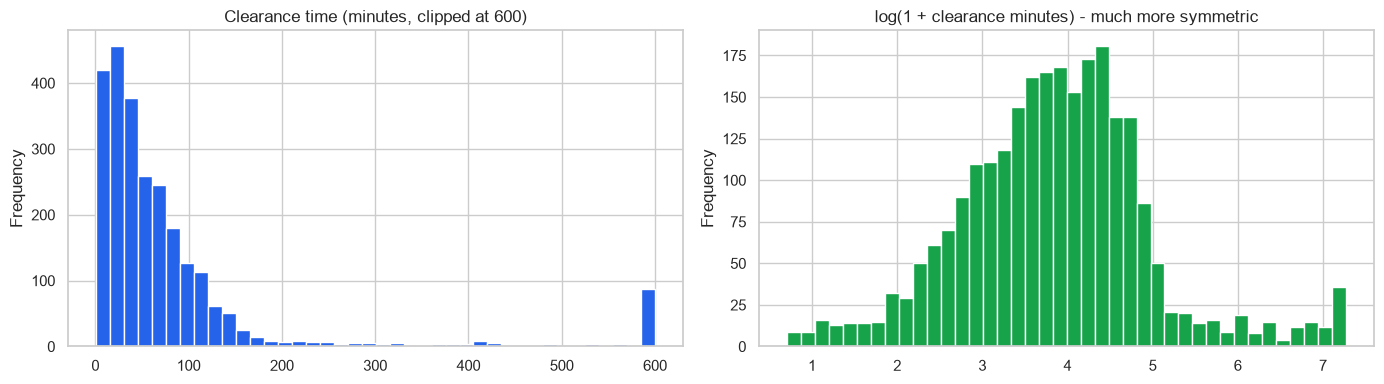

In [7]:
labelled = add_targets(raw)
dur = labelled['clearance_minutes'].dropna()
print('Events with a usable clearance time:', len(dur))
print(dur.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dur.clip(upper=600).plot.hist(bins=40, ax=axes[0], color='#2563eb')
axes[0].set_title('Clearance time (minutes, clipped at 600)')
np.log1p(dur).plot.hist(bins=40, ax=axes[1], color='#16a34a')
axes[1].set_title('log(1 + clearance minutes) - much more symmetric')
plt.tight_layout(); plt.show()

### 3.1 A note on data leakage (important!)

Our first model scored a *perfect* AUC of 1.0 - a classic warning sign. Investigation showed the `endlatitude/endlongitude` ("event has an end point") flag correlated **0.99** with `road_closure`: a closed road is logged as a start->end **stretch**, so the end point exists *because* of the closure. That information is not legitimately available when forecasting a fresh event, so we **exclude** it. After removing it the classifier scores a realistic ROC-AUC ~0.80.

## 4. Feature engineering

`build_features()` produces one clean row per event from:
- **Categoricals:** `event_type, event_cause, priority, veh_type, corridor, zone`
- **Temporal:** `hour, day_of_week, month, is_weekend, is_peak_hour, is_night`
- **Geo/flags:** `latitude, longitude, has_junction`

Missing categoricals become an explicit `"unknown"` category (so no rows are dropped).

In [8]:
X = build_features(raw)
print('Feature matrix:', X.shape)
print('Categorical:', CATEGORICAL_FEATURES)
print('Numeric    :', NUMERIC_FEATURES)
X.head()

Feature matrix: (8173, 15)
Categorical: ['event_type', 'event_cause', 'priority', 'veh_type', 'corridor', 'zone']
Numeric    : ['latitude', 'longitude', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_night', 'has_junction']


,event_type,event_cause,priority,veh_type,corridor,zone,latitude,longitude,hour,day_of_week,month,is_weekend,is_peak_hour,is_night,has_junction
0,unplanned,vehicle_breakdown,High,lcv,Tumkur Road,unknown,13.040004,77.518099,17.0,3.0,3.0,0,1,0,0
1,unplanned,vehicle_breakdown,High,heavy_vehicle,ORR East 1,unknown,12.921876,77.645158,4.0,1.0,1.0,0,0,1,0
2,unplanned,others,Low,unknown,Non-corridor,Central Zone 2,12.955622,77.585708,6.0,5.0,11.0,1,0,0,1
3,unplanned,tree_fall,Low,unknown,Non-corridor,unknown,13.006147,77.579435,17.0,3.0,3.0,0,1,0,0
4,unplanned,vehicle_breakdown,Low,private_bus,Non-corridor,unknown,12.953980,77.585233,4.0,1.0,1.0,0,0,1,1


## 5. Model 1 - Clearance-duration regression (impact forecast)

We compare Linear Regression, Random Forest and Gradient Boosting inside a single sklearn `Pipeline` (one-hot encode categoricals + scale numerics). The target is `log1p(minutes)`; metrics are reported back in real **minutes**.

Clearance time is inherently noisy (two identical-looking breakdowns can clear in 10 or 90 minutes), so we expect a **modest R²** but an operationally useful **median error of ~25 minutes** - good enough to drive severity buckets.

In [9]:
from ml.train import train_regression, train_classification

reg_mask = labelled['clearance_minutes'].notna()
Xr, yr = X[reg_mask], labelled.loc[reg_mask, 'clearance_minutes']
reg_name, reg_pipe, reg_results = train_regression(Xr, yr)
print('Best regressor:', reg_name)
pd.DataFrame(reg_results).T

Best regressor: grad_boost


,mae_minutes,r2
linear,65.26,0.0792
random_forest,64.38,0.1210
grad_boost,63.37,0.1107


## 6. Model 2 - Road-closure classification (barricading / diversion)

Only ~8% of events need a closure, so the classes are imbalanced - we use `class_weight='balanced'` and judge models by **ROC-AUC** (and F1).

In [10]:
yc = labelled['road_closure']
clf_name, clf_pipe, clf_results = train_classification(X, yc)
print('Best classifier:', clf_name, '| positives:', int(yc.sum()), 'of', len(yc))
pd.DataFrame(clf_results).T

Best classifier: random_forest | positives: 676 of 8173


,roc_auc,f1
logreg,0.7596,0.3146
random_forest,0.7984,0.4254
grad_boost,0.7872,0.3429


### 6.1 Which features drive road-closure risk?
Reading the importances out of the fitted pipeline tells operations staff *why* the model flags an event - construction, tree-fall and accident causes dominate, as expected.

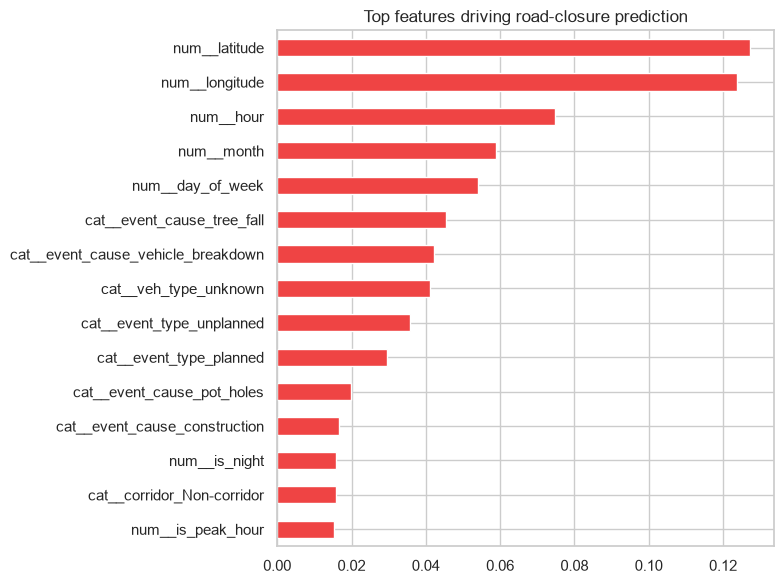

In [11]:
model = clf_pipe.named_steps['model']
if hasattr(model, 'feature_importances_'):
    names = clf_pipe.named_steps['prep'].get_feature_names_out()
    imp = pd.Series(model.feature_importances_, index=names).sort_values()
    imp.tail(15).plot.barh(figsize=(8,6), color='#ef4444')
    plt.title('Top features driving road-closure prediction'); plt.tight_layout(); plt.show()
else:
    print('Best model has no feature_importances_ (linear model).')

## 7. From predictions to a deployment plan

The `recommend()` function (in `backend/app/recommender.py`) combines the two predictions into a transparent severity score (0-100) and a concrete plan: **manpower, barricades and a diversion decision**. Thresholds are anchored to the data-driven duration quantiles. Let's run it on a few scenarios.

In [12]:
sys.path.insert(0, os.path.abspath('../backend/app'))
from recommender import recommend

q = yr.quantile([0.5,0.75,0.9]).round(1)
quantiles = {'0.5': q[0.5], '0.75': q[0.75], '0.9': q[0.9]}

def plan(ev):
    Xe = build_features(pd.DataFrame([ev]))
    dmin = float(np.expm1(reg_pipe.predict(Xe)[0]))
    prob = float(clf_pipe.predict_proba(Xe)[0,1])
    r = recommend(duration_min=dmin, closure_prob=prob,
                  event_cause=ev['event_cause'], corridor=ev['corridor'],
                  requires_road_closure=ev.get('requires_road_closure', False),
                  duration_quantiles=quantiles)
    return r.to_dict()

scenarios = [
    {'event_type':'planned','event_cause':'public_event','priority':'High',
     'corridor':'Mysore Road','zone':'Central Zone 2','veh_type':'unknown',
     'latitude':12.95,'longitude':77.58,'start_datetime':'2024-03-15T18:00:00Z',
     'requires_road_closure':True},
    {'event_type':'unplanned','event_cause':'vehicle_breakdown','priority':'Low',
     'corridor':'Non-corridor','zone':'unknown','veh_type':'lcv',
     'latitude':13.0,'longitude':77.6,'start_datetime':'2024-03-15T03:00:00Z',
     'requires_road_closure':False},
    {'event_type':'unplanned','event_cause':'accident','priority':'High',
     'corridor':'Hosur Road','zone':'South Zone 1','veh_type':'heavy_vehicle',
     'latitude':12.9,'longitude':77.62,'start_datetime':'2024-03-15T09:30:00Z',
     'requires_road_closure':False},
]
for s in scenarios:
    r = plan(s)
    print(f"\n{s['event_cause']:18s} on {s['corridor']:14s} -> {r['severity']:8s} "
          f"(~{r['predicted_clearance_min']:.0f} min, closure p={r['road_closure_probability']:.2f})")
    print(f"   manpower={r['manpower']}  barricades={r['barricades']}  divert={r['diversion_required']}")
    print(f"   advice: {r['diversion_advice']}")


public_event       on Mysore Road    -> High     (~54 min, closure p=0.68)
   manpower=14  barricades=10  divert=True
   advice: Set up a signed diversion off 'Mysore Road'. Pre-position traffic wardens at the two nearest upstream junctions and alert control room to retime adjacent signals.

vehicle_breakdown  on Non-corridor   -> Low      (~38 min, closure p=0.10)
   manpower=2  barricades=0  divert=False
   advice: No full diversion needed. Manage with lane coning and on-site officers; keep one lane flowing.



accident           on Hosur Road     -> Low      (~44 min, closure p=0.17)
   manpower=4  barricades=4  divert=False
   advice: No full diversion needed. Manage with lane coning and on-site officers; keep one lane flowing.


## 8. Persist the trained artifacts for the backend

`ml.train.main()` retrains on the full data, picks the best model for each task, and writes `duration_model.joblib`, `closure_model.joblib` and `metadata.json` into `backend/models/`. The FastAPI service loads exactly these files - so this notebook *is* the training pipeline, not a separate copy.

In [13]:
from ml.train import main as train_main
train_main(CSV, os.path.abspath('../backend/models'))

Loading ../Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv ...
Regression rows: 2520


  best regressor: grad_boost -> {'mae_minutes': 63.37, 'r2': 0.1107}
Classification rows: 8173 (positives=676)


  best classifier: random_forest -> {'roc_auc': 0.7984, 'f1': 0.4254}
Saved models + metadata to /Users/ashish.sahu/Downloads/prem2/backend/models


## 9. Summary & how this solves the problem

| Pain point (today) | What we deliver |
|--------------------|-----------------|
| Impact not quantified in advance | A **clearance-duration forecast** + 0-100 **severity score** for every event |
| Resource deployment is experience-driven | A **data-driven recommender** for manpower, barricades and diversions with a written rationale |
| No post-event learning | Models retrain from the **same event log**; new resolved events continuously improve them |

These artifacts are served by the **FastAPI backend** and visualised in the **React + Mappls** dashboard, where an operator drops a pin, enters event details, and instantly gets a forecast and deployment plan on the live Bengaluru map.